# 02 - Evaluation No-RAG (allineato a utility condivise)

Notebook di valutazione baseline **senza retrieval RAG**, usando dataset condivisi in `data/evaluation`:
- `questions.csv` (MCQ)
- `questions_no_hint.csv` (domanda aperta + judge)

Le utility di parsing, prompt e metriche sono centralizzate in `src/legal_indexing/rag_runtime/benchmarking.py`.


## 1) Setup ambiente e configurazione API

Carichiamo `.env`, prepariamo endpoint chat e modelli runtime.


In [4]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd


def _find_repo_root_for_bootstrap(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'notebooks' / 'pipelines' / 'common' / 'bootstrap.py').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Project root non trovato. Avvia il notebook dentro il repository.')


_BOOTSTRAP_ROOT = _find_repo_root_for_bootstrap(Path.cwd().resolve())
if str(_BOOTSTRAP_ROOT) not in sys.path:
    sys.path.insert(0, str(_BOOTSTRAP_ROOT))

from notebooks.pipelines.common.bootstrap import bootstrap_notebook

PROJECT_ROOT, SRC = bootstrap_notebook(start=Path.cwd().resolve())

from legal_indexing.rag_runtime import (
    McqAnswer,
    align_record,
    build_comparison_table,
    build_dataset_summary,
    build_judge_prompt,
    build_mcq_prompt,
    build_no_hint_prompt,
    level_sort_key,
    load_valid_rows,
    post_structured_chat,
    resolve_ollama_chat_url,
    validate_judge_output,
    validate_mcq_output,
    validate_no_hint_output,
)
from legal_indexing.rag_runtime.schemas import JudgeResult, NoHintAnswer, schema_to_json_dict

MCQ_CSV_PATH = PROJECT_ROOT / 'data' / 'evaluation' / 'questions.csv'
NO_HINT_CSV_PATH = PROJECT_ROOT / 'data' / 'evaluation' / 'questions_no_hint.csv'

START_POS = 0
N_QUESTIONS = 100
TIMEOUT_SEC = 120
RUN_SMOKE = True
SMOKE_POS = START_POS

UTOPIA_API_KEY = os.getenv('UTOPIA_API_KEY', '')
if not UTOPIA_API_KEY:
    raise RuntimeError('UTOPIA_API_KEY mancante')

BASE_URL = os.getenv('UTOPIA_BASE_URL', 'https://utopia.hpc4ai.unito.it')
UTOPIA_OLLAMA_CHAT_URL = os.getenv('UTOPIA_OLLAMA_CHAT_URL', '')
API_URL = resolve_ollama_chat_url(BASE_URL, explicit_url=UTOPIA_OLLAMA_CHAT_URL)
CHAT_MODEL = os.getenv('UTOPIA_CHAT_MODEL', 'SLURM.gpt-oss:120b')
JUDGE_MODEL = os.getenv('UTOPIA_JUDGE_MODEL', CHAT_MODEL)

HEADERS = {
    'Authorization': f'Bearer {UTOPIA_API_KEY}',
    'Content-Type': 'application/json',
}

print(json.dumps({
    'project_root': str(PROJECT_ROOT),
    'mcq_csv': str(MCQ_CSV_PATH),
    'no_hint_csv': str(NO_HINT_CSV_PATH),
    'api_url': API_URL,
    'chat_model': CHAT_MODEL,
    'judge_model': JUDGE_MODEL,
}, ensure_ascii=False, indent=2))


{
  "project_root": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite",
  "mcq_csv": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/evaluation/questions.csv",
  "no_hint_csv": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/evaluation/questions_no_hint.csv",
  "api_url": "https://utopia.hpc4ai.unito.it/ollama/api/chat",
  "chat_model": "SLURM.gpt-oss:120b",
  "judge_model": "SLURM.gpt-oss:120b"
}


## 2) Load dataset e validazione allineamento

Confermiamo che i due dataset siano allineati per indice su righe valide.


In [5]:
mcq_rows = load_valid_rows(MCQ_CSV_PATH)
no_hint_rows = load_valid_rows(NO_HINT_CSV_PATH)

max_available = min(len(mcq_rows), len(no_hint_rows))
if START_POS < 0 or START_POS >= max_available:
    raise IndexError(f"START_POS fuori range: {START_POS}")

end_pos = min(START_POS + N_QUESTIONS, max_available)
EVAL_POSITIONS = list(range(START_POS, end_pos))
if not EVAL_POSITIONS:
    raise RuntimeError("Nessuna posizione da valutare")

for pos in EVAL_POSITIONS:
    _ = align_record(pos, no_hint_rows, mcq_rows)

print(json.dumps({
    "mcq_valid_rows": len(mcq_rows),
    "no_hint_valid_rows": len(no_hint_rows),
    "eval_start": EVAL_POSITIONS[0],
    "eval_end": EVAL_POSITIONS[-1],
    "eval_n": len(EVAL_POSITIONS),
}, ensure_ascii=False, indent=2))


{
  "mcq_valid_rows": 100,
  "no_hint_valid_rows": 100,
  "eval_start": 0,
  "eval_end": 99,
  "eval_n": 100
}


## 3) Smoke test opzionale

Eseguiamo una domanda singola su entrambi i flussi (MCQ e no-hint+judge).


In [6]:
smoke_result = None

if RUN_SMOKE:
    record = align_record(SMOKE_POS, no_hint_rows, mcq_rows)

    mcq_call = post_structured_chat(
        api_url=API_URL,
        headers=HEADERS,
        payload_schema=schema_to_json_dict(McqAnswer),
        prompt=build_mcq_prompt(record),
        model=CHAT_MODEL,
        timeout=TIMEOUT_SEC,
    )
    mcq_obj = validate_mcq_output(mcq_call["structured"])

    no_hint_call = post_structured_chat(
        api_url=API_URL,
        headers=HEADERS,
        payload_schema=schema_to_json_dict(NoHintAnswer),
        prompt=build_no_hint_prompt(record),
        model=CHAT_MODEL,
        timeout=TIMEOUT_SEC,
    )
    no_hint_obj = validate_no_hint_output(no_hint_call["structured"])

    judge_call = post_structured_chat(
        api_url=API_URL,
        headers=HEADERS,
        payload_schema=schema_to_json_dict(JudgeResult),
        prompt=build_judge_prompt(record, no_hint_obj.answer_text),
        model=JUDGE_MODEL,
        timeout=TIMEOUT_SEC,
    )
    judge_obj = validate_judge_output(judge_call["structured"])

    smoke_result = {
        "qid": record["qid"],
        "level": record["level"],
        "mcq": {
            "predicted_label": mcq_obj.answer_label,
            "ground_truth_label": record["ground_truth_label_mcq"],
            "is_correct": mcq_obj.answer_label == record["ground_truth_label_mcq"],
        },
        "no_hint": {
            "predicted_answer": no_hint_obj.answer_text,
            "judge_result": judge_obj.model_dump(),
            "final_binary_score": int(judge_obj.score),
        },
    }

    print(json.dumps(smoke_result, ensure_ascii=False, indent=2))
else:
    print("RUN_SMOKE=False: smoke test saltato")


{
  "qid": "1",
  "level": "L1",
  "mcq": {
    "predicted_label": "D",
    "ground_truth_label": "D",
    "is_correct": true
  },
  "no_hint": {
    "predicted_answer": "Gli organi tipici di un'azienda USL sono: la Direzione generale, il Consiglio di amministrazione, il Collegio sindacale, il Comitato tecnico e il Comitato di programmazione e controllo, oltre a eventuali commissioni consultive e organi di vigilanza previsti dalla normativa regionale.",
    "judge_result": {
      "score": 0,
      "confidence": 0.99,
      "matched_option_label": "NONE",
      "is_semantically_equivalent": false,
      "justification": "La risposta del modello elenca molti organi (Consiglio di amministrazione, Comitato tecnico, ecc.) oltre a Direzione generale e Collegio sindacale, mentre la soluzione ufficiale richiede solo \"Il direttore generale il collegio sindacale\" (opzione D). Pertanto la risposta non è semanticamente equivalente all'opzione corretta."
    },
    "final_binary_score": 0
  }
}


## 4) Batch MCQ evaluation

Valutazione diretta su label A-F.


In [7]:
mcq_results: list[dict[str, Any]] = []

for idx, pos in enumerate(EVAL_POSITIONS, start=1):
    record = align_record(pos, no_hint_rows, mcq_rows)

    predicted_label = ""
    raw_structured = None
    error = None
    score = None

    try:
        call_out = post_structured_chat(
            api_url=API_URL,
            headers=HEADERS,
            payload_schema=schema_to_json_dict(McqAnswer),
            prompt=build_mcq_prompt(record),
            model=CHAT_MODEL,
            timeout=TIMEOUT_SEC,
        )
        raw_structured = call_out["structured"]
        mcq_obj = validate_mcq_output(raw_structured)
        predicted_label = mcq_obj.answer_label
        score = 1 if predicted_label == record["ground_truth_label_mcq"] else 0
    except Exception as exc:
        error = str(exc)

    item = {
        "qid": record["qid"],
        "level": record["level"],
        "pos": pos,
        "question_mcq_full": record["question_mcq_full"],
        "ground_truth_label": record["ground_truth_label_mcq"],
        "predicted_label": predicted_label,
        "score": score,
        "is_correct": (score == 1) if score in (0, 1) else None,
        "error": error,
        "raw_response": raw_structured,
    }
    mcq_results.append(item)

    status = f"score={score}" if score in (0, 1) else "score=NA"
    print(f"[MCQ {idx}/{len(EVAL_POSITIONS)}] qid={item['qid']} level={item['level']} {status}")


[MCQ 1/100] qid=1 level=L1 score=1
[MCQ 2/100] qid=2 level=L2 score=1
[MCQ 3/100] qid=3 level=L3 score=1
[MCQ 4/100] qid=4 level=L4 score=1
[MCQ 5/100] qid=5 level=L1 score=1
[MCQ 6/100] qid=6 level=L2 score=1
[MCQ 7/100] qid=7 level=L3 score=0
[MCQ 8/100] qid=8 level=L4 score=1
[MCQ 9/100] qid=9 level=L1 score=1
[MCQ 10/100] qid=10 level=L2 score=1
[MCQ 11/100] qid=11 level=L3 score=1
[MCQ 12/100] qid=12 level=L4 score=0
[MCQ 13/100] qid=13 level=L1 score=1
[MCQ 14/100] qid=14 level=L2 score=0
[MCQ 15/100] qid=15 level=L3 score=0
[MCQ 16/100] qid=16 level=L4 score=1
[MCQ 17/100] qid=17 level=L1 score=1
[MCQ 18/100] qid=18 level=L2 score=1
[MCQ 19/100] qid=19 level=L3 score=1
[MCQ 20/100] qid=20 level=L4 score=1
[MCQ 21/100] qid=21 level=L1 score=0
[MCQ 22/100] qid=22 level=L2 score=0
[MCQ 23/100] qid=23 level=L3 score=1
[MCQ 24/100] qid=24 level=L4 score=0
[MCQ 25/100] qid=25 level=L1 score=1
[MCQ 26/100] qid=26 level=L2 score=1
[MCQ 27/100] qid=27 level=L3 score=1
[MCQ 28/100] qid=28

## 5) Batch no-hint + judge evaluation

Step1 risposta aperta, step2 judge semantico 0/1.


In [8]:
no_hint_results: list[dict[str, Any]] = []

for idx, pos in enumerate(EVAL_POSITIONS, start=1):
    record = align_record(pos, no_hint_rows, mcq_rows)

    predicted_answer = ""
    raw_step1 = None
    judge_result = None
    raw_judge = None
    final_binary_score = None
    error = None

    try:
        step1_out = post_structured_chat(
            api_url=API_URL,
            headers=HEADERS,
            payload_schema=schema_to_json_dict(NoHintAnswer),
            prompt=build_no_hint_prompt(record),
            model=CHAT_MODEL,
            timeout=TIMEOUT_SEC,
        )
        raw_step1 = step1_out["structured"]
        step1_obj = validate_no_hint_output(raw_step1)
        predicted_answer = step1_obj.answer_text

        judge_out = post_structured_chat(
            api_url=API_URL,
            headers=HEADERS,
            payload_schema=schema_to_json_dict(JudgeResult),
            prompt=build_judge_prompt(record, predicted_answer),
            model=JUDGE_MODEL,
            timeout=TIMEOUT_SEC,
        )
        raw_judge = judge_out["structured"]
        judge_obj = validate_judge_output(raw_judge)
        judge_result = judge_obj.model_dump()
        final_binary_score = int(judge_obj.score)
    except Exception as exc:
        error = str(exc)

    item = {
        "qid": record["qid"],
        "level": record["level"],
        "pos": pos,
        "predicted_answer": predicted_answer,
        "judge_context": {
            "question_mcq_full": record["question_mcq_full"],
            "correct_option_label": record["ground_truth_label_mcq"],
            "correct_option_text": record["correct_option_text"],
        },
        "judge_result": judge_result,
        "final_binary_score": final_binary_score,
        "error": error,
        "raw_step1": raw_step1,
        "raw_judge": raw_judge,
    }
    no_hint_results.append(item)

    status = f"score={final_binary_score}" if final_binary_score in (0, 1) else "score=NA"
    print(f"[NO_HINT {idx}/{len(EVAL_POSITIONS)}] qid={item['qid']} level={item['level']} {status}")


[NO_HINT 1/100] qid=1 level=L1 score=0
[NO_HINT 2/100] qid=2 level=L2 score=1
[NO_HINT 3/100] qid=3 level=L3 score=0
[NO_HINT 4/100] qid=4 level=L4 score=0
[NO_HINT 5/100] qid=5 level=L1 score=0
[NO_HINT 6/100] qid=6 level=L2 score=0
[NO_HINT 7/100] qid=7 level=L3 score=0
[NO_HINT 8/100] qid=8 level=L4 score=0
[NO_HINT 9/100] qid=9 level=L1 score=0
[NO_HINT 10/100] qid=10 level=L2 score=1
[NO_HINT 11/100] qid=11 level=L3 score=0
[NO_HINT 12/100] qid=12 level=L4 score=0
[NO_HINT 13/100] qid=13 level=L1 score=1
[NO_HINT 14/100] qid=14 level=L2 score=0
[NO_HINT 15/100] qid=15 level=L3 score=0
[NO_HINT 16/100] qid=16 level=L4 score=1
[NO_HINT 17/100] qid=17 level=L1 score=0
[NO_HINT 18/100] qid=18 level=L2 score=1
[NO_HINT 19/100] qid=19 level=L3 score=0
[NO_HINT 20/100] qid=20 level=L4 score=0
[NO_HINT 21/100] qid=21 level=L1 score=0
[NO_HINT 22/100] qid=22 level=L2 score=0
[NO_HINT 23/100] qid=23 level=L3 score=0
[NO_HINT 24/100] qid=24 level=L4 score=0
[NO_HINT 25/100] qid=25 level=L1 s

## 6) Aggregazioni metriche e confronto

Produciamo summary globali/per livello e dashboard comparativa.


In [9]:
mcq_summary = build_dataset_summary("MCQ", mcq_results, score_key="score")
no_hint_summary = build_dataset_summary("No-Hint + Judge", no_hint_results, score_key="final_binary_score")
comparison_table = build_comparison_table(mcq_summary, no_hint_summary)

mcq_acc = mcq_summary.get("accuracy")
no_hint_acc = no_hint_summary.get("accuracy")
global_delta = (no_hint_acc - mcq_acc) if (mcq_acc is not None and no_hint_acc is not None) else None

comparison_summary = {
    "global": {
        "mcq_accuracy": mcq_acc,
        "no_hint_accuracy": no_hint_acc,
        "delta_no_hint_minus_mcq": global_delta,
    },
    "by_level": comparison_table["level_rows"],
}

print("=== GLOBAL SUMMARY ===")
print(json.dumps({
    "mcq": {
        "processed": mcq_summary["processed"],
        "judged": mcq_summary["judged"],
        "correct": mcq_summary["score_sum"],
        "accuracy": mcq_summary["accuracy"],
        "errors": mcq_summary["errors"],
    },
    "no_hint": {
        "processed": no_hint_summary["processed"],
        "judged": no_hint_summary["judged"],
        "correct": no_hint_summary["score_sum"],
        "accuracy": no_hint_summary["accuracy"],
        "errors": no_hint_summary["errors"],
    },
    "comparison": comparison_summary["global"],
}, ensure_ascii=False, indent=2))

comparison_df = pd.DataFrame(comparison_table["global_rows"])
comparison_by_level_df = pd.DataFrame(comparison_table["level_rows"])

display(comparison_df)
display(comparison_by_level_df)


=== GLOBAL SUMMARY ===
{
  "mcq": {
    "processed": 100,
    "judged": 100,
    "correct": 77,
    "accuracy": 0.77,
    "errors": 0
  },
  "no_hint": {
    "processed": 100,
    "judged": 100,
    "correct": 35,
    "accuracy": 0.35,
    "errors": 0
  },
  "comparison": {
    "mcq_accuracy": 0.77,
    "no_hint_accuracy": 0.35,
    "delta_no_hint_minus_mcq": -0.42000000000000004
  }
}


,dataset,processed,judged,correct,accuracy,errors
0,MCQ,100,100,77,0.77,0
1,No-Hint + Judge,100,100,35,0.35,0


,level,mcq_correct,mcq_judged,mcq_accuracy,no_hint_correct,no_hint_judged,no_hint_accuracy,delta_no_hint_minus_mcq
0,L1,20,25,0.80,8,25,0.32,-0.48
1,L2,19,25,0.76,13,25,0.52,-0.24
2,L3,17,25,0.68,6,25,0.24,-0.44
3,L4,21,25,0.84,8,25,0.32,-0.52


## 7) Dashboard e analisi errori rapida

Visualizziamo accuracy globale/per livello e alcuni casi errati.


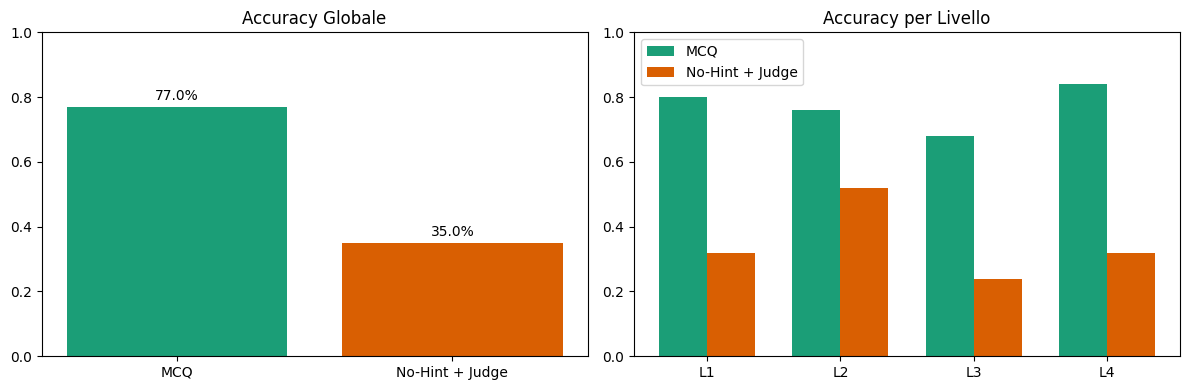

MCQ error/wrong cases: 23
{
  "qid": "7",
  "level": "L3",
  "ground_truth_label": "B",
  "predicted_label": "A",
  "score": 0,
  "error": null
}
{
  "qid": "12",
  "level": "L4",
  "ground_truth_label": "D",
  "predicted_label": "C",
  "score": 0,
  "error": null
}
{
  "qid": "14",
  "level": "L2",
  "ground_truth_label": "D",
  "predicted_label": "C",
  "score": 0,
  "error": null
}
{
  "qid": "15",
  "level": "L3",
  "ground_truth_label": "D",
  "predicted_label": "A",
  "score": 0,
  "error": null
}
{
  "qid": "21",
  "level": "L1",
  "ground_truth_label": "D",
  "predicted_label": "B",
  "score": 0,
  "error": null
}
No-Hint error/wrong cases: 65
{
  "qid": "1",
  "level": "L1",
  "predicted_answer": "Gli organi principali dell'azienda USL sono: Consiglio di amministrazione, Direzione generale, Collegio dei dirigenti, Comitato tecnico, Comitato di programmazione e controllo, e l'organo di vigilanza (es. Commissione di vigilanza).",
  "final_binary_score": 0,
  "judge_matched_optio

In [10]:
all_levels = sorted(
    set(mcq_summary["by_level"].keys()) | set(no_hint_summary["by_level"].keys()),
    key=level_sort_key,
)

mcq_global_acc = mcq_summary["accuracy"] if mcq_summary["accuracy"] is not None else 0.0
no_hint_global_acc = no_hint_summary["accuracy"] if no_hint_summary["accuracy"] is not None else 0.0

mcq_level_acc = [(mcq_summary["by_level"].get(lvl, {}).get("accuracy") or 0.0) for lvl in all_levels]
no_hint_level_acc = [(no_hint_summary["by_level"].get(lvl, {}).get("accuracy") or 0.0) for lvl in all_levels]

x = list(range(len(all_levels)))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(["MCQ", "No-Hint + Judge"], [mcq_global_acc, no_hint_global_acc], color=["#1b9e77", "#d95f02"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy Globale")
for bar, val in zip(bars, [mcq_global_acc, no_hint_global_acc]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.1%}", ha="center")

axes[1].bar([i - width / 2 for i in x], mcq_level_acc, width, label="MCQ", color="#1b9e77")
axes[1].bar([i + width / 2 for i in x], no_hint_level_acc, width, label="No-Hint + Judge", color="#d95f02")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(x, all_levels)
axes[1].set_title("Accuracy per Livello")
axes[1].legend()

plt.tight_layout()
plt.show()

TOP_K_ERRORS = 5
print("MCQ error/wrong cases:", len([r for r in mcq_results if r.get("error") or r.get("score") == 0]))
for row in [r for r in mcq_results if r.get("error") or r.get("score") == 0][:TOP_K_ERRORS]:
    print(json.dumps({
        "qid": row["qid"],
        "level": row["level"],
        "ground_truth_label": row["ground_truth_label"],
        "predicted_label": row["predicted_label"],
        "score": row["score"],
        "error": row["error"],
    }, ensure_ascii=False, indent=2))

print("No-Hint error/wrong cases:", len([r for r in no_hint_results if r.get("error") or r.get("final_binary_score") == 0]))
for row in [r for r in no_hint_results if r.get("error") or r.get("final_binary_score") == 0][:TOP_K_ERRORS]:
    print(json.dumps({
        "qid": row["qid"],
        "level": row["level"],
        "predicted_answer": row.get("predicted_answer"),
        "final_binary_score": row.get("final_binary_score"),
        "judge_matched_option": (row.get("judge_result") or {}).get("matched_option_label"),
        "judge_justification": (row.get("judge_result") or {}).get("justification"),
        "error": row.get("error"),
    }, ensure_ascii=False, indent=2))
